<a href="https://colab.research.google.com/github/Vino8801/AI-Job-Replacement/blob/main/Chocolate_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df= pd.read_csv('/content/drive/MyDrive/Chocolate_Sales.csv')
df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,12/11/2022,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,3/14/2023,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,12/21/2023,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,12/18/2023,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,8/18/2023,4.4,2.75,187.44,214,549.69


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         20000 non-null  object 
 1   Product          20000 non-null  object 
 2   Country          20000 non-null  object 
 3   Channel          20000 non-null  object 
 4   Salesperson      20000 non-null  object 
 5   Order_Date       20000 non-null  object 
 6   Discount_Pct     19999 non-null  float64
 7   Price_per_Box    19999 non-null  float64
 8   Marketing_Spend  20000 non-null  float64
 9   Boxes_Shipped    20000 non-null  int64  
 10  Amount           20000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 1.7+ MB


In [3]:
df.isnull().sum()

,0
Order_ID,0
Product,0
Country,0
Channel,0
Salesperson,0
Order_Date,0
Discount_Pct,1
Price_per_Box,1
Marketing_Spend,0
Boxes_Shipped,0


**Convert Order_Date**

In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

In [5]:
print("Missing dates:",df['Order_Date'].isnull().sum())

Missing dates: 117


In [6]:
numeric_colums = ['Discount_Pct','Price_per_Box','Marketing_Spend','Boxes_Shipped','Amount']
for col in numeric_colums:
  df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df[numeric_colums].dtypes

,0
Discount_Pct,float64
Price_per_Box,float64
Marketing_Spend,float64
Boxes_Shipped,int64
Amount,float64


**OBJECTIVE 1**

**Overall sales performance**

In [8]:
total_orders = df['Order_ID'].nunique()
total_revenue = df['Amount'].sum()
total_boxes = df['Boxes_Shipped'].sum()
average_order_value = df['Amount'].mean()
average_boxes_per_order = df['Boxes_Shipped'].mean()

print("Total Orders:",total_orders)
print("Total Revenue: $", f"{total_revenue:,.2f}")
print("Total Boxes Shipped:", f"{total_boxes:,.0f}")
print("Average Order Value: $", f"{average_order_value:,.2f}")
print("Average Boxes per Order:", f"{average_boxes_per_order:,.2f}")


Total Orders: 20000
Total Revenue: $ 10,313,334.32
Total Boxes Shipped: 2,821,227
Average Order Value: $ 515.95
Average Boxes per Order: 141.06


**Revenue by product**

In [9]:
product_sales = df.groupby('Product').agg(
    Total_Revenue=('Amount','sum'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Number_of_Orders=('Order_ID','nunique'),
    Average_Order_Value=('Amount','mean')
).sort_values('Total_Revenue',ascending=False)
product_sales

,Total_Revenue,Total_Boxes,Number_of_Orders,Average_Order_Value
Product,,,,
70% Dark Bar,2623787.65,708597,6353,413.455350
Mixed Assortment Box,2011521.25,555792,2197,915.576354
Truffle Gift Box,1876559.09,506790,3130,599.731253
Milk Classic Bar,626337.29,171911,1594,393.180973
Almond Crunch Bar,604991.88,165368,951,636.833558
Pralines Gift Box,596959.39,166881,1329,449.179375
Choco Coins Bag,478835.95,133826,674,710.439095
Mint Dark Bar,371142.73,99496,1107,335.268952
White Choco Bar,322991.77,90915,717,451.105824


**Calculate percentage contribution by product**

In [10]:
product_sales['Revenue_Contribution_%'] =(
    product_sales['Total_Revenue']/total_revenue*100
)
product_sales

,Total_Revenue,Total_Boxes,Number_of_Orders,Average_Order_Value,Revenue_Contribution_%
Product,,,,,
70% Dark Bar,2623787.65,708597,6353,413.455350,25.440731
Mixed Assortment Box,2011521.25,555792,2197,915.576354,19.504083
Truffle Gift Box,1876559.09,506790,3130,599.731253,18.195465
Milk Classic Bar,626337.29,171911,1594,393.180973,6.073082
Almond Crunch Bar,604991.88,165368,951,636.833558,5.866113
Pralines Gift Box,596959.39,166881,1329,449.179375,5.788229
Choco Coins Bag,478835.95,133826,674,710.439095,4.642882
Mint Dark Bar,371142.73,99496,1107,335.268952,3.598669
White Choco Bar,322991.77,90915,717,451.105824,3.131788


**Product revenue visualisation**

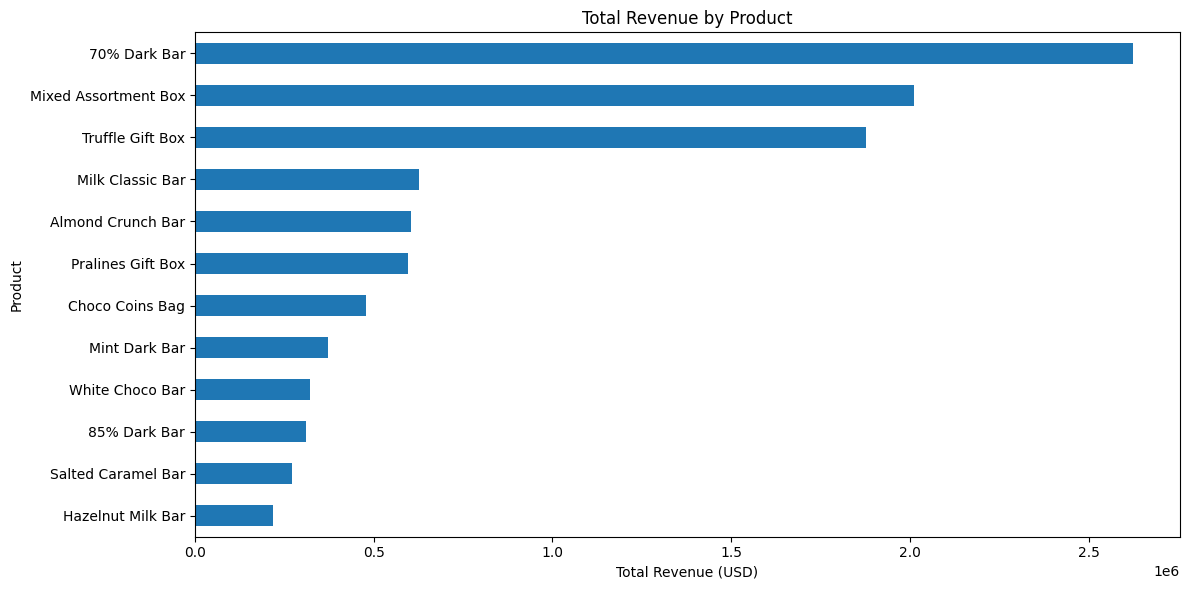

In [11]:
plt.figure(figsize=(12,6))
product_sales['Total_Revenue'].sort_values().plot(kind='barh')
plt.title('Total Revenue by Product')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

**Product boxes shipped**

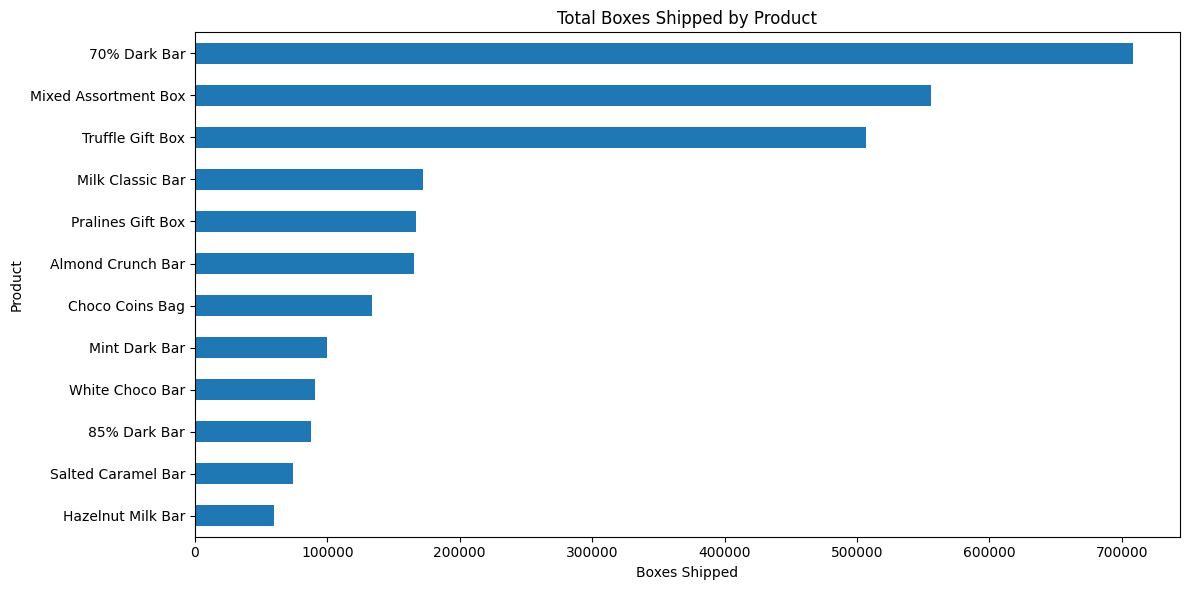

In [12]:
plt.figure(figsize=(12,6))
product_sales['Total_Boxes'].sort_values().plot(kind='barh')
plt.title('Total Boxes Shipped by Product')
plt.xlabel('Boxes Shipped')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

**Revenue contribution by product**

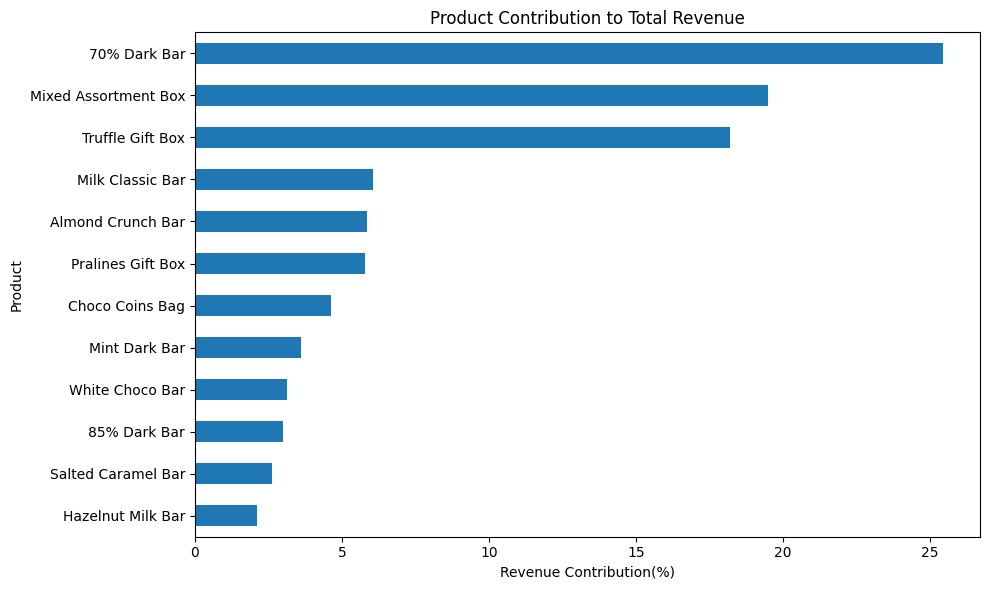

In [13]:
plt.figure(figsize=(10,6))
product_sales['Revenue_Contribution_%'].sort_values().plot(kind='barh')
plt.title('Product Contribution to Total Revenue')
plt.xlabel('Revenue Contribution(%)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


**Country sales analysis**

In [14]:
country_sales =df.groupby('Country').agg(
    Total_Revenue=('Amount','sum'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Number_of_Orders=('Order_ID','nunique'),
    Average_Order_Value=('Amount', 'mean')
).sort_values('Total_Revenue',ascending=False)
country_sales

,Total_Revenue,Total_Boxes,Number_of_Orders,Average_Order_Value
Country,,,,
Australia,4246404.97,1149154,9242,459.766671
Brazil,3692760.52,1014258,5269,701.245826
Germany,1151477.77,320462,2560,449.971774
India,665466.43,183255,1769,376.395040
Japan,557224.63,154098,1160,480.366060


**Country revenue contribution**

In [15]:
country_sales['Revenue_Contribution_%'] =(
    country_sales['Total_Revenue']/total_revenue*100
)
country_sales

,Total_Revenue,Total_Boxes,Number_of_Orders,Average_Order_Value,Revenue_Contribution_%
Country,,,,,
Australia,4246404.97,1149154,9242,459.766671,41.173929
Brazil,3692760.52,1014258,5269,701.245826,35.805690
Germany,1151477.77,320462,2560,449.971774,11.164942
India,665466.43,183255,1769,376.395040,6.452486
Japan,557224.63,154098,1160,480.366060,5.402953


**Revenue by country chart**

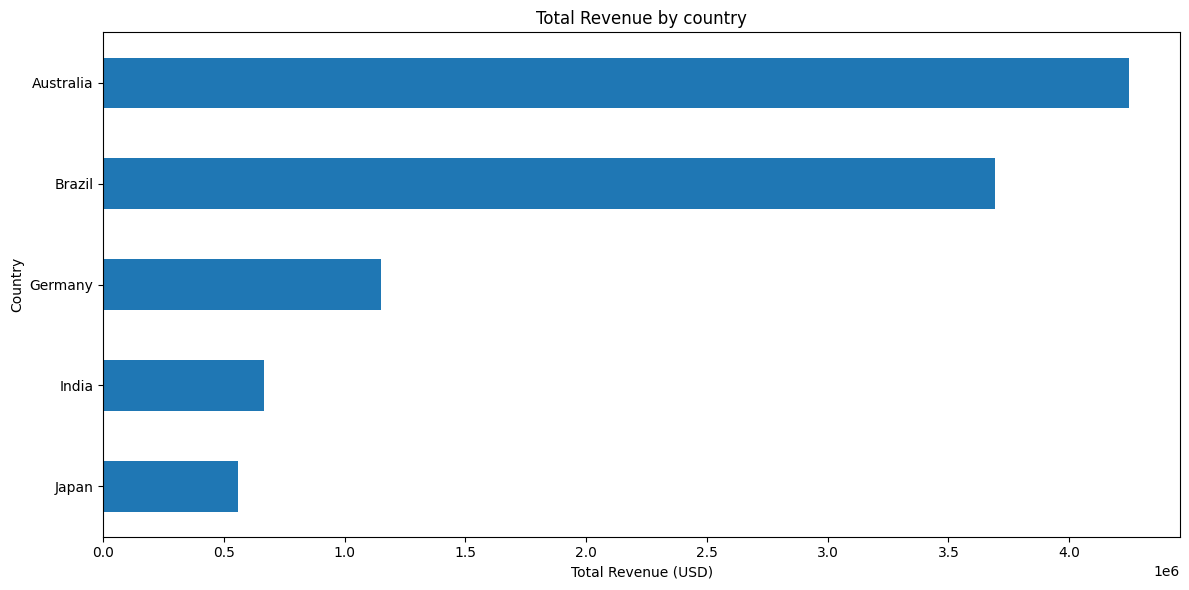

In [16]:
plt.figure(figsize=(12,6))
country_sales['Total_Revenue'].sort_values().plot(kind='barh')
plt.title('Total Revenue by country')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Boxes shipped by country**

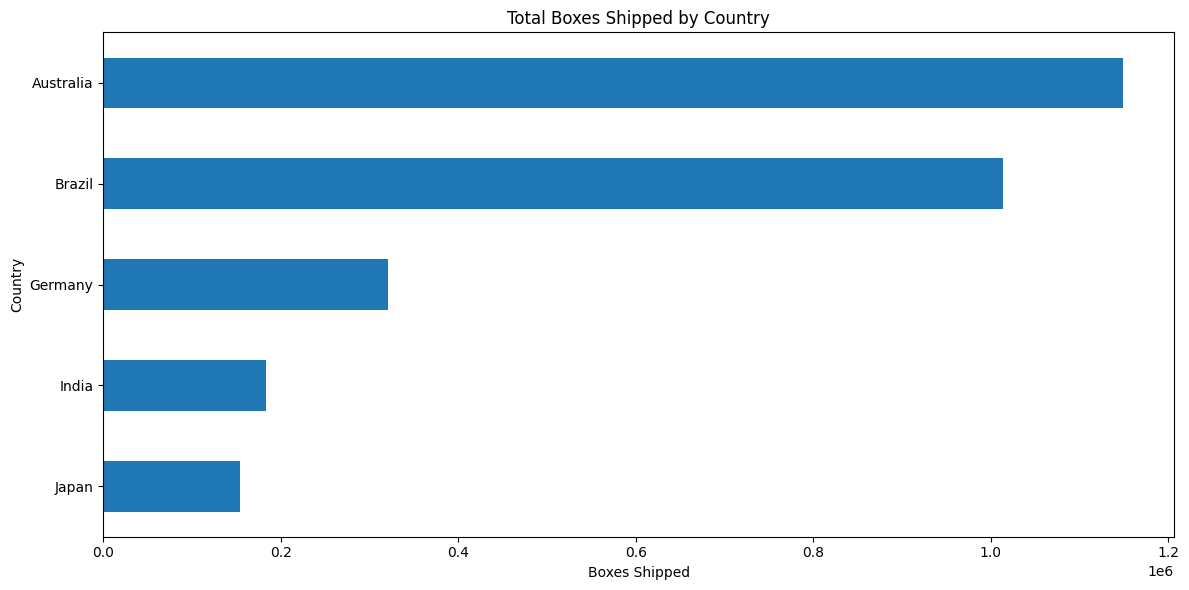

In [17]:
plt.figure(figsize=(12,6))
country_sales['Total_Boxes'].sort_values().plot(kind='barh')
plt.title('Total Boxes Shipped by Country')
plt.xlabel('Boxes Shipped')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Sales channel analysis**

In [18]:
channel_sales = df.groupby('Channel').agg(
    Total_Revenue=('Amount','sum'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Number_of_Orders=('Order_ID','nunique'),
    Average_Order_Value=('Amount','mean')
).sort_values('Total_Revenue', ascending=False)
channel_sales

,Total_Revenue,Total_Boxes,Number_of_Orders,Average_Order_Value
Channel,,,,
Retail,5375864.21,1477040,11638,462.121913
Wholesale,3821504.95,1039912,5951,642.809916
Online,1115965.16,304275,2411,462.864023


**Channel revenue contribution**

In [19]:
channel_sales['Revenue_Contribution_%']=(
    channel_sales['Total_Revenue']/total_revenue*100
)
channel_sales

,Total_Revenue,Total_Boxes,Number_of_Orders,Average_Order_Value,Revenue_Contribution_%
Channel,,,,,
Retail,5375864.21,1477040,11638,462.121913,52.125375
Wholesale,3821504.95,1039912,5951,642.809916,37.054020
Online,1115965.16,304275,2411,462.864023,10.820605


**Revenue by channel**

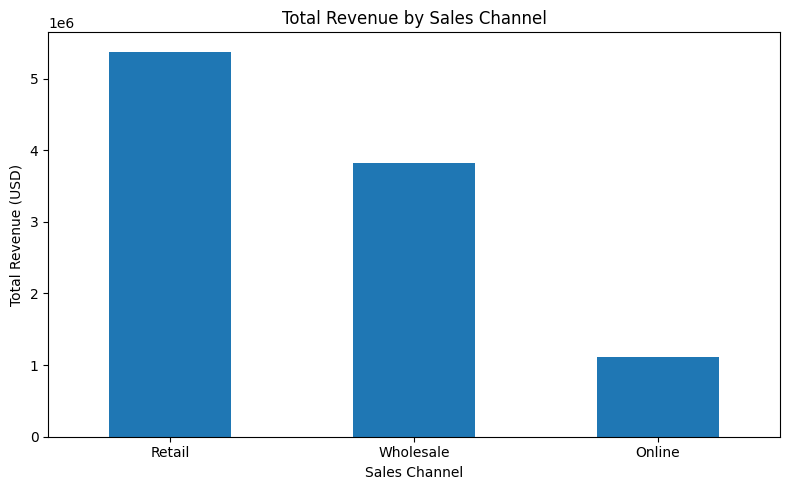

In [20]:
plt.figure(figsize=(8,5))
channel_sales['Total_Revenue'].plot(kind='bar')
plt.title('Total Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Boxes shipped by channel**

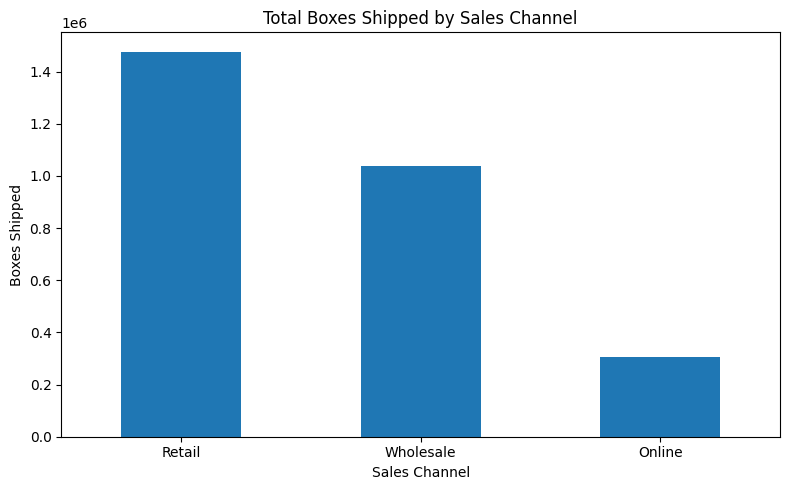

In [21]:
plt.figure(figsize=(8,5))
channel_sales['Total_Boxes'].plot(kind='bar')
plt.title('Total Boxes Shipped by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Boxes Shipped')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Average order value by channel**

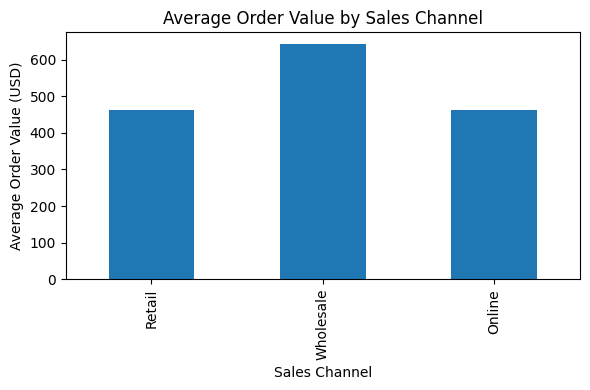

In [22]:
plt.figure(figsize=(6,4))
channel_sales['Average_Order_Value'].plot(kind='bar')
plt.title('Average Order Value by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Average Order Value (USD)')
plt.xticks
plt.tight_layout()
plt.show()


***Product * Country analysis***

In [23]:
product_country = pd.pivot_table(df, values='Amount',index='Product',columns='Country',aggfunc='sum',fill_value=0)
product_country

Country,Australia,Brazil,Germany,India,Japan
Product,,,,,
70% Dark Bar,1092298.61,935416.93,281956.15,168464.48,145651.48
85% Dark Bar,125511.60,115541.87,33198.47,19384.31,16553.85
Almond Crunch Bar,243761.96,224595.09,65588.21,41612.72,29433.90
Choco Coins Bag,187350.35,175640.87,54808.61,32634.41,28401.71
Hazelnut Milk Bar,90520.62,79995.11,23333.63,10754.66,13415.03
Milk Classic Bar,260000.07,229745.51,65394.15,39400.74,31796.82
Mint Dark Bar,157329.57,125236.70,39001.44,25548.89,24026.13
Mixed Assortment Box,809097.24,740352.61,247785.05,117692.41,96593.94
Pralines Gift Box,230011.16,226166.14,68291.22,36879.61,35611.26


**Prouct * Country heatmap**

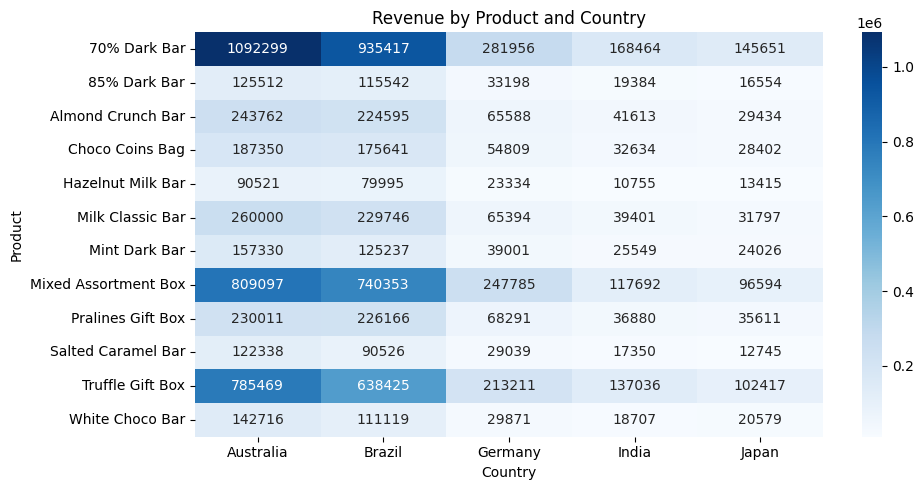

In [24]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(product_country, annot=True, fmt='.0f',cmap='Blues')
plt.title('Revenue by Product and Country')
plt.xlabel('Country')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


**Country Channel analysis**

In [25]:
country_channel =pd.pivot_table(df,values='Amount', index='Country', columns='Channel',aggfunc='sum',fill_value=0)
country_channel

Channel,Online,Retail,Wholesale
Country,,,
Australia,455875.47,2206516.18,1584013.32
Brazil,388251.22,1930897.96,1373611.34
Germany,130752.24,605494.44,415231.09
India,78459.45,339814.80,247192.18
Japan,62626.78,293140.83,201457.02


**Country * Channel heatmap**

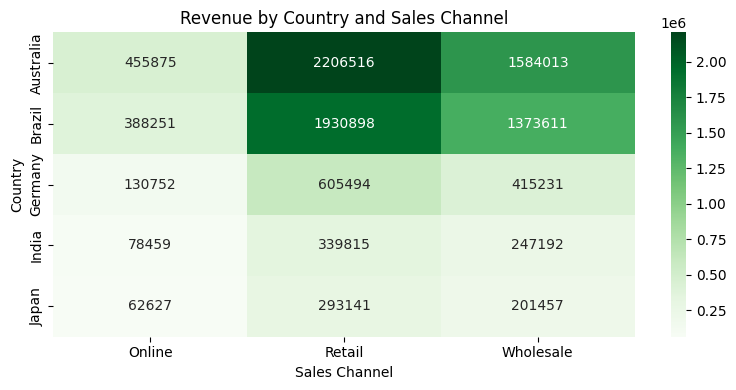

In [26]:
plt.figure(figsize=(8,4))

sns.heatmap(country_channel, annot=True, fmt='.0f', cmap='Greens')
plt.title('Revenue by Country and Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Identify the top revenue contributors**

In [27]:
top_products = product_sales.head(5)
print("Top 5 products by Revenue:")
display(top_products[['Total_Revenue','Revenue_Contribution_%']])

Top 5 products by Revenue:


,Total_Revenue,Revenue_Contribution_%
Product,,
70% Dark Bar,2623787.65,25.440731
Mixed Assortment Box,2011521.25,19.504083
Truffle Gift Box,1876559.09,18.195465
Milk Classic Bar,626337.29,6.073082
Almond Crunch Bar,604991.88,5.866113


In [28]:
top_countries = country_sales.head(5)
print("Top 5 Countries by Revenue:")
display(top_countries[['Total_Revenue','Revenue_Contribution_%']])

Top 5 Countries by Revenue:


,Total_Revenue,Revenue_Contribution_%
Country,,
Australia,4246404.97,41.173929
Brazil,3692760.52,35.805690
Germany,1151477.77,11.164942
India,665466.43,6.452486
Japan,557224.63,5.402953


In [29]:
print("Sales Channel Performance:")
display(channel_sales[['Total_Revenue','Revenue_Contribution_%']])

Sales Channel Performance:


,Total_Revenue,Revenue_Contribution_%
Channel,,
Retail,5375864.21,52.125375
Wholesale,3821504.95,37.054020
Online,1115965.16,10.820605


**Find the single highest performing product country combination**

In [30]:
product_country_combination = (df.groupby(['Product','Country'])['Amount'].sum().sort_values(ascending=False))
print("Top Product Country Combination:")
display(product_country_combination.head(10))

Top Product Country Combination:


Product               Country  
70% Dark Bar          Australia    1092298.61
                      Brazil        935416.93
Mixed Assortment Box  Australia     809097.24
Truffle Gift Box      Australia     785469.42
Mixed Assortment Box  Brazil        740352.61
Truffle Gift Box      Brazil        638424.84
70% Dark Bar          Germany       281956.15
Milk Classic Bar      Australia     260000.07
Mixed Assortment Box  Germany       247785.05
Almond Crunch Bar     Australia     243761.96
Name: Amount, dtype: float64

**Find the highest performing country channel combination**

In [31]:
country_channel_combination =(df.groupby(['Country','Channel'])['Amount'].sum().sort_values(ascending=False))
print("Top Country Channel Combination:")
display(country_channel_combination.head(10))

Top Country Channel Combination:


,,Amount
Country,Channel,
Australia,Retail,2206516.18
Brazil,Retail,1930897.96
Australia,Wholesale,1584013.32
Brazil,Wholesale,1373611.34
Germany,Retail,605494.44
Australia,Online,455875.47
Germany,Wholesale,415231.09
Brazil,Online,388251.22
India,Retail,339814.80


**OBJECTIVE 2**

In [32]:
print(df[['Discount_Pct','Boxes_Shipped','Amount']].head())
print(df[['Discount_Pct','Boxes_Shipped','Amount']].dtypes)

   Discount_Pct  Boxes_Shipped  Amount
0           3.5             71  912.31
1           9.4             84  245.91
2           4.9             35  583.70
3          15.0             92  211.27
4           4.4            214  549.69
Discount_Pct     float64
Boxes_Shipped      int64
Amount           float64
dtype: object


In [33]:
df['Discount_Pct'] = pd.to_numeric(df['Discount_Pct'],errors='coerce')
df['Boxes_Shipped'] = pd.to_numeric(df['Boxes_Shipped'],errors='coerce')
df['Amount'] = pd.to_numeric(df['Amount'],errors='coerce')

In [34]:
df[['Discount_Pct','Boxes_Shipped','Amount']].isnull().sum()

,0
Discount_Pct,1
Boxes_Shipped,0
Amount,11


**Descriptive statistics of discounts**

In [35]:
discount_stats = df['Discount_Pct'].describe()
print(discount_stats)

count    19999.000000
mean        13.195825
std          6.395757
min          0.200000
25%          8.300000
50%         12.800000
75%         17.600000
max         35.600000
Name: Discount_Pct, dtype: float64


In [36]:
print("Average Discount:",df['Discount_Pct'].mean())
print("Median Discount:", df['Discount_Pct'].median())
print("Minimum Discount:",df['Discount_Pct'].min())
print("Maximum Discount:",df['Discount_Pct'].max())

Average Discount: 13.195825291264564
Median Discount: 12.8
Minimum Discount: 0.2
Maximum Discount: 35.6


**Distribution of discount percentages**

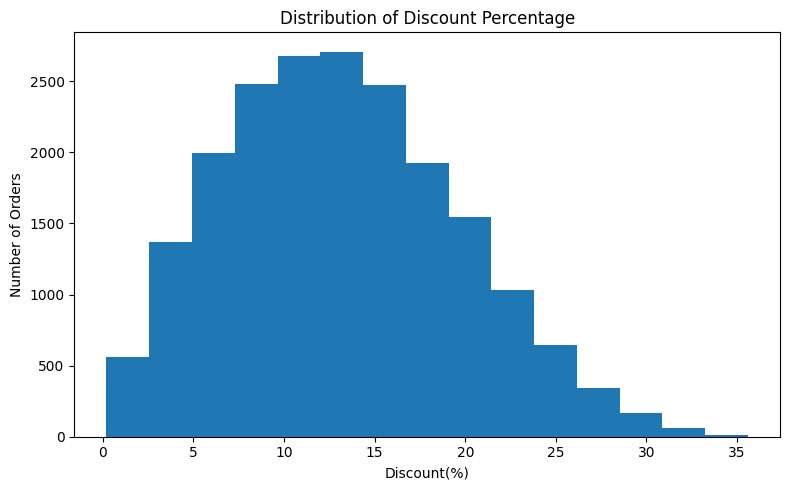

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df['Discount_Pct'].dropna(),bins=15)
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount(%)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Discount vs Boxes Shipped**

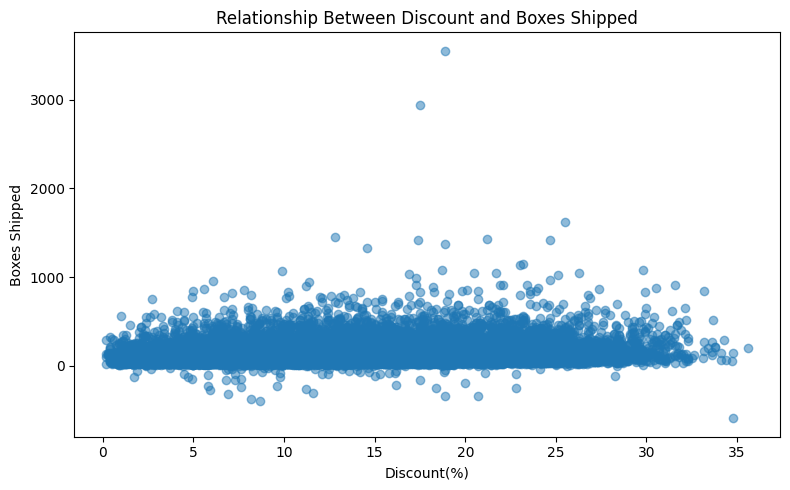

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount_Pct'],df['Boxes_Shipped'],alpha=0.5)
plt.title('Relationship Between Discount and Boxes Shipped')
plt.xlabel('Discount(%)')
plt.ylabel('Boxes Shipped')
plt.tight_layout()
plt.show()

**Calculate correlation- Discount vs Boxes Shipped**

In [39]:
discount_boxes_corr = df[['Discount_Pct','Boxes_Shipped']].corr()
print(discount_boxes_corr)

               Discount_Pct  Boxes_Shipped
Discount_Pct       1.000000       0.187722
Boxes_Shipped      0.187722       1.000000


**Discount vs Total Order Value**

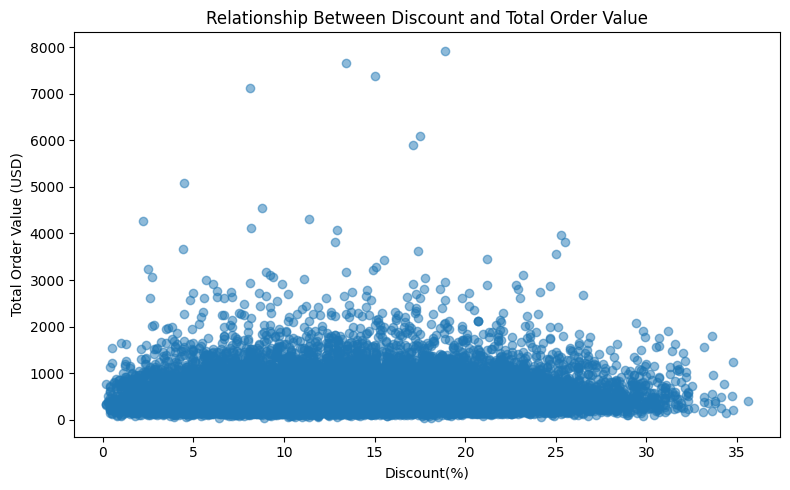

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount_Pct'],df['Amount'],alpha=0.5)
plt.title('Relationship Between Discount and Total Order Value')
plt.xlabel('Discount(%)')
plt.ylabel('Total Order Value (USD)')
plt.tight_layout()
plt.show()

**Correlation - Discount vs Amount**

In [41]:
correlation_amount = df['Discount_Pct'].corr(df['Amount'])
print("Correlation between Discount and Total Order Value:",round(correlation_amount,3))

Correlation between Discount and Total Order Value: 0.063


In [42]:
df['Discount_Pct'] =pd.to_numeric(df['Discount_Pct'],errors='coerce')

df['Discount_Category'] = pd.cut(df['Discount_Pct'],bins=[-np.inf,5,10,np.inf],labels=['Low Discount','Medium Discount','High Discount'])

**Compare sales performance by discount category**

In [43]:
discount_analysis =df.groupby ('Discount_Category',observed=True).agg(
    Number_of_Orders=('Order_ID','nunique'),
    Total_Revenue=('Amount','sum'),
    Average_Order_Value=('Amount','mean'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Average_Boxes=('Boxes_Shipped','mean'),
    Average_Discount=('Discount_Pct','mean')
)

discount_analysis

,Number_of_Orders,Total_Revenue,Average_Order_Value,Total_Boxes,Average_Boxes,Average_Discount
Discount_Category,,,,,,
Low Discount,2015,952667.65,473.257650,220510,109.434243,3.331261
Medium Discount,4867,2429388.29,499.463053,596004,122.458188,7.713674
High Discount,13117,6930972.85,528.638002,2004602,152.824731,16.745321


**Average Boxes by discount category**

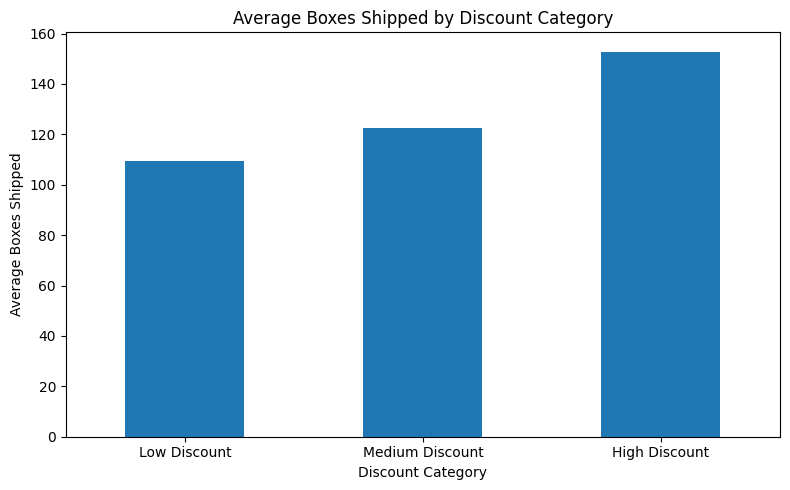

In [44]:
plt.figure(figsize=(8,5))
discount_analysis['Average_Boxes'].plot(kind='bar')
plt.title('Average Boxes Shipped by Discount Category')
plt.xlabel('Discount Category')
plt.ylabel('Average Boxes Shipped')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Average order value by discount category**

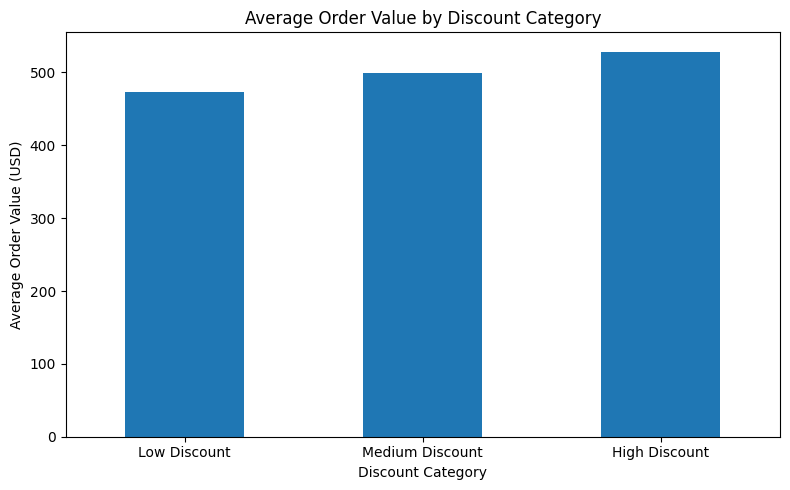

In [45]:
plt.figure(figsize=(8,5))
discount_analysis['Average_Order_Value'].plot(kind='bar')
plt.title('Average Order Value by Discount Category')
plt.xlabel('Discount Category')
plt.ylabel('Average Order Value (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Total revenue by discount category**

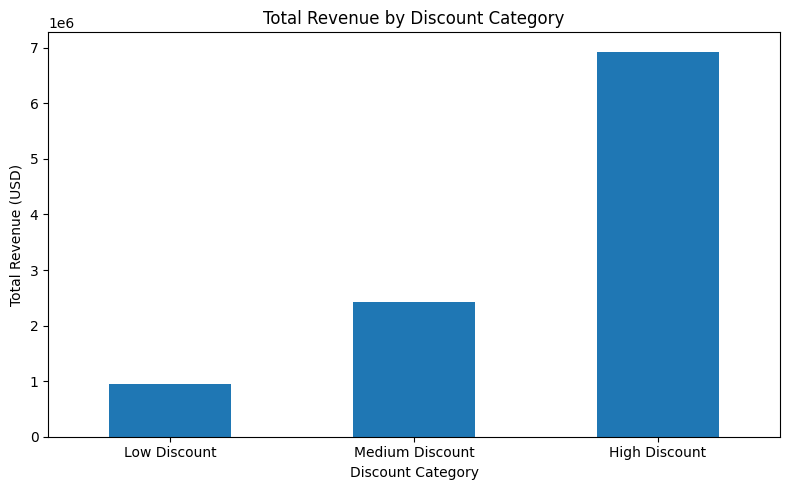

In [46]:
plt.figure(figsize=(8,5))
discount_analysis['Total_Revenue'].plot(kind='bar')
plt.title('Total Revenue by Discount Category')
plt.xlabel('Discount Category')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Total boxes shipped by discount category**

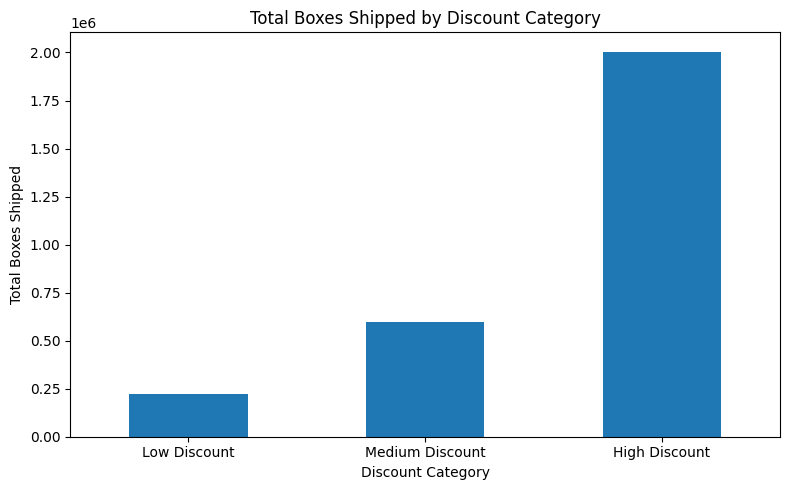

In [47]:
plt.figure(figsize=(8,5))
discount_analysis['Total_Boxes'].plot(kind='bar')
plt.title('Total Boxes Shipped by Discount Category')
plt.xlabel('Discount Category')
plt.ylabel('Total Boxes Shipped')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Anlaysis discount by sales channel**

In [48]:
discount_channel = df.groupby('Channel').agg(
    Average_Discount =('Discount_Pct','mean'),
    Total_Revenue=('Amount','sum'),
    Average_Order_Values=('Amount','mean'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Average_Boxes=('Boxes_Shipped','mean')
).sort_values('Average_Discount',ascending=False)

discount_channel

,Average_Discount,Total_Revenue,Average_Order_Values,Total_Boxes,Average_Boxes
Channel,,,,,
Wholesale,13.207854,3821504.95,642.809916,1039912,174.745757
Retail,13.191288,5375864.21,462.121913,1477040,126.915278
Online,13.188034,1115965.16,462.864023,304275,126.202820


**Visualise average discount by channel**

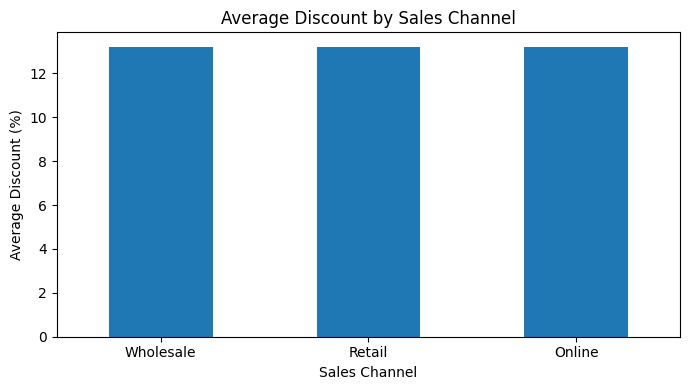

In [49]:
plt.figure(figsize=(7,4))
discount_channel['Average_Discount'].plot(kind='bar')
plt.title('Average Discount by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Average Discount (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Compare discount and sales performance by channel**

In [50]:
channel_discount_performance = df.groupby('Channel').agg(
    Average_Discount=('Discount_Pct','mean'),
    Average_Order_Value=('Amount','mean'),
    Average_Boxes=('Boxes_Shipped','mean')
)
channel_discount_performance

,Average_Discount,Average_Order_Value,Average_Boxes
Channel,,,
Online,13.188034,462.864023,126.202820
Retail,13.191288,462.121913,126.915278
Wholesale,13.207854,642.809916,174.745757


**Analyse discount by product**

In [51]:
product_discount = df.groupby('Product').agg(
    Average_Discount=('Discount_Pct','mean'),
    Average_Order_Value=('Amount','mean'),
    Average_Boxes=('Boxes_Shipped','mean'),
    Total_Revenue=('Amount','sum')
).sort_values('Total_Revenue',ascending=False)

product_discount

,Average_Discount,Average_Order_Value,Average_Boxes,Total_Revenue
Product,,,,
70% Dark Bar,13.221585,413.455350,111.537384,2623787.65
Mixed Assortment Box,13.038457,915.576354,252.977697,2011521.25
Truffle Gift Box,13.156668,599.731253,161.913738,1876559.09
Milk Classic Bar,13.400056,393.180973,107.848808,626337.29
Almond Crunch Bar,12.810925,636.833558,173.888538,604991.88
Pralines Gift Box,13.275384,449.179375,125.568849,596959.39
Choco Coins Bag,13.173531,710.439095,198.554896,478835.95
Mint Dark Bar,13.268681,335.268952,89.878952,371142.73
White Choco Bar,13.204644,451.105824,126.799163,322991.77


**Correlation matrix**

In [52]:
correlation_matrix = df[['Discount_Pct','Boxes_Shipped','Amount','Price_per_Box','Marketing_Spend']].corr()
print(correlation_matrix)

                 Discount_Pct  Boxes_Shipped    Amount  Price_per_Box  \
Discount_Pct         1.000000       0.187722  0.062807      -0.044490   
Boxes_Shipped        0.187722       1.000000  0.583519      -0.408568   
Amount               0.062807       0.583519  1.000000       0.269947   
Price_per_Box       -0.044490      -0.408568  0.269947       1.000000   
Marketing_Spend      0.050693       0.323808  0.372312       0.006846   

                 Marketing_Spend  
Discount_Pct            0.050693  
Boxes_Shipped           0.323808  
Amount                  0.372312  
Price_per_Box           0.006846  
Marketing_Spend         1.000000  


**Correlation heatmap**

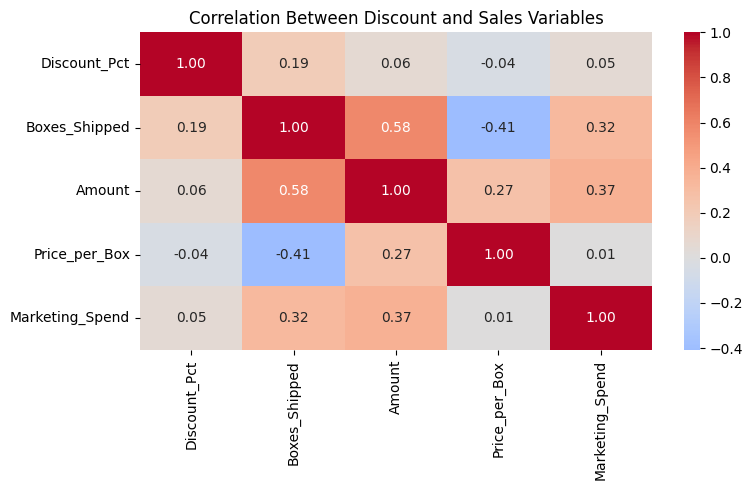

In [53]:
plt.figure(figsize=(8,5))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlation Between Discount and Sales Variables')
plt.tight_layout()
plt.show()

**OBJECTIVE 3**

**Convert columns**

In [54]:
df['Marketing_spend'] = pd.to_numeric(df['Marketing_Spend'],errors='coerce')
df['Amount'] = pd.to_numeric(df['Amount'],errors='coerce')
df['Boxes_Shipped'] = pd.to_numeric(df['Boxes_Shipped'],errors='coerce')
print(df[['Marketing_Spend','Amount','Boxes_Shipped']].dtypes)

Marketing_Spend    float64
Amount             float64
Boxes_Shipped        int64
dtype: object


In [55]:
df[['Marketing_Spend','Amount','Boxes_Shipped']].isnull().sum()

,0
Marketing_Spend,0
Amount,11
Boxes_Shipped,0


**Descriptive statistics of marketing expenditure**

In [56]:
marketing_stats = df['Marketing_Spend'].describe()
print(marketing_stats)

count    20000.000000
mean        95.674501
std         66.241102
min          4.630000
25%         53.067500
50%         78.810000
75%        118.362500
max        798.220000
Name: Marketing_Spend, dtype: float64


**Distribution of marketing expenditure**

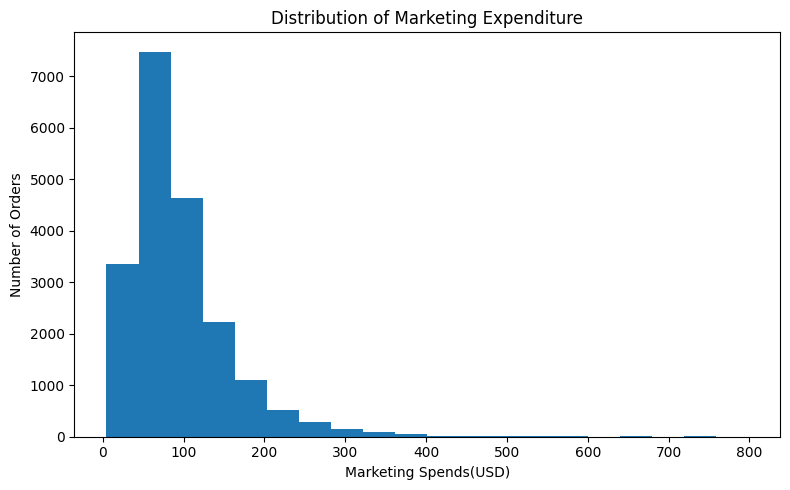

In [57]:
plt.figure(figsize=(8,5))
plt.hist(df['Marketing_Spend'].dropna(),bins=20)
plt.title('Distribution of Marketing Expenditure')
plt.xlabel('Marketing Spends(USD)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


**Relationship between marketing spend and revenue**

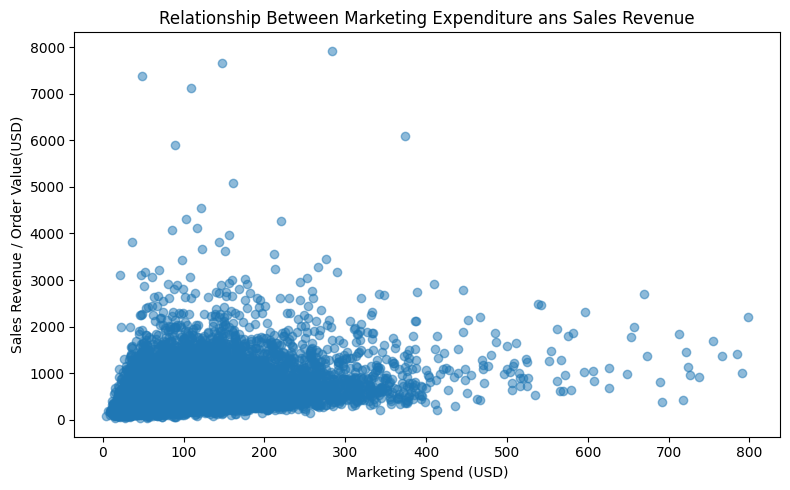

In [58]:
plt.figure(figsize=(8,5))
plt.scatter(df['Marketing_Spend'],df['Amount'],alpha=0.5)
plt.title('Relationship Between Marketing Expenditure ans Sales Revenue')
plt.xlabel('Marketing Spend (USD)')
plt.ylabel('Sales Revenue / Order Value(USD)')
plt.tight_layout()
plt.show()

**Add a regression trend line**

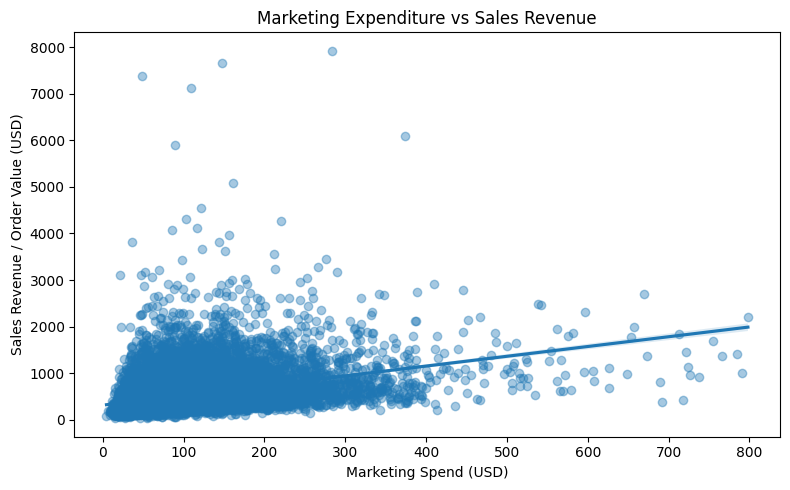

In [59]:
plt.figure(figsize=(8,5))
sns.regplot(data=df,x='Marketing_Spend',y='Amount',scatter_kws={'alpha':0.4},line_kws={})
plt.title('Marketing Expenditure vs Sales Revenue')
plt.xlabel('Marketing Spend (USD)')
plt.ylabel('Sales Revenue / Order Value (USD)')
plt.tight_layout()
plt.show()


**Calculate correlation**

In [60]:
marketing_revenue_corr =df[['Marketing_Spend','Amount']].corr()
print(marketing_revenue_corr)

                 Marketing_Spend    Amount
Marketing_Spend         1.000000  0.372312
Amount                  0.372312  1.000000


**Marketing Spend vs Boxes Shipped**

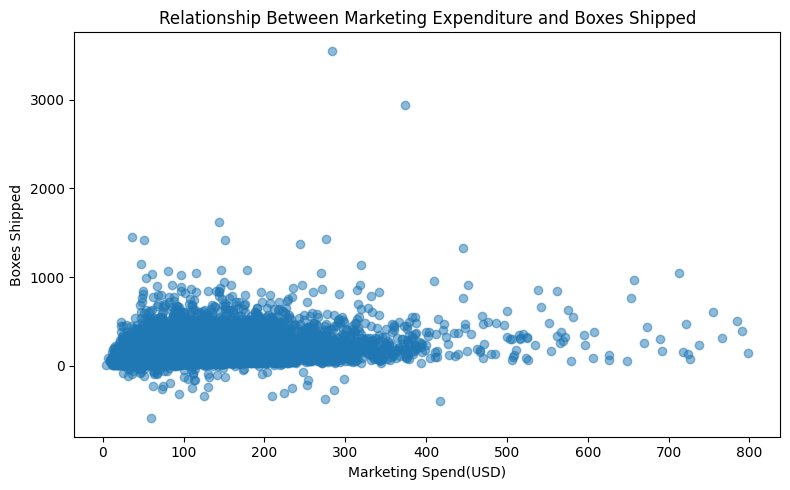

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(df['Marketing_Spend'],df['Boxes_Shipped'],alpha=0.5)
plt.title('Relationship Between Marketing Expenditure and Boxes Shipped')
plt.xlabel('Marketing Spend(USD)')
plt.ylabel('Boxes Shipped')
plt.tight_layout()
plt.show()

In [63]:
correlation_boxes =df['Marketing_Spend'].corr(df['Boxes_Shipped'])
print("Correlation between Marketing Spend and Boxes Shipped:",round(correlation_boxes,3))

Correlation between Marketing Spend and Boxes Shipped: 0.324


**Calculate Marketing Efficiency**

In [64]:
df['Marketing_Efficiency'] =(df['Amount'] / df['Marketing_Spend'])

In [65]:
print("Zero marketing spend:",(df['Marketing_Spend'] ==0).sum())

Zero marketing spend: 0


In [66]:
df['Marketing_Efficiency'] = np.where(df['Marketing_Spend'] > 0, df['Amount'] / df['Marketing_Spend'], np.nan )

**Overall Marketing efficiency**

In [67]:
total_marketing_spend = df['Marketing_Spend'].sum()
total_revenue = df['Amount'].sum()
overall_marketing_efficiency =(total_revenue /total_marketing_spend)
print("Overall Marketing Efficiency:", round(overall_marketing_efficiency,2))

Overall Marketing Efficiency: 5.39


**Marketing efficiency by country**

In [68]:
country_marketing = df.groupby('Country').agg(
    Total_Marketing_Spend=('Marketing_Spend','sum'),
    Total_Revenue=('Amount','sum'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Number_of_Orders=('Order_ID','nunique')
)
country_marketing['Marketing_Efficiency'] =(
    country_marketing['Total_Revenue'] / country_marketing['Total_Marketing_Spend']
)
country_marketing=country_marketing.sort_values('Marketing_Efficiency',ascending=False)

country_marketing

,Total_Marketing_Spend,Total_Revenue,Total_Boxes,Number_of_Orders,Marketing_Efficiency
Country,,,,,
Brazil,507270.499534,3692760.52,1014258,5269,7.279667
Japan,112108.620000,557224.63,154098,1160,4.970400
Australia,884290.932488,4246404.97,1149154,9242,4.802045
Germany,240721.713700,1151477.77,320462,2560,4.783440
India,169098.251212,665466.43,183255,1769,3.935383


**Visualise marketing efficiency by country**

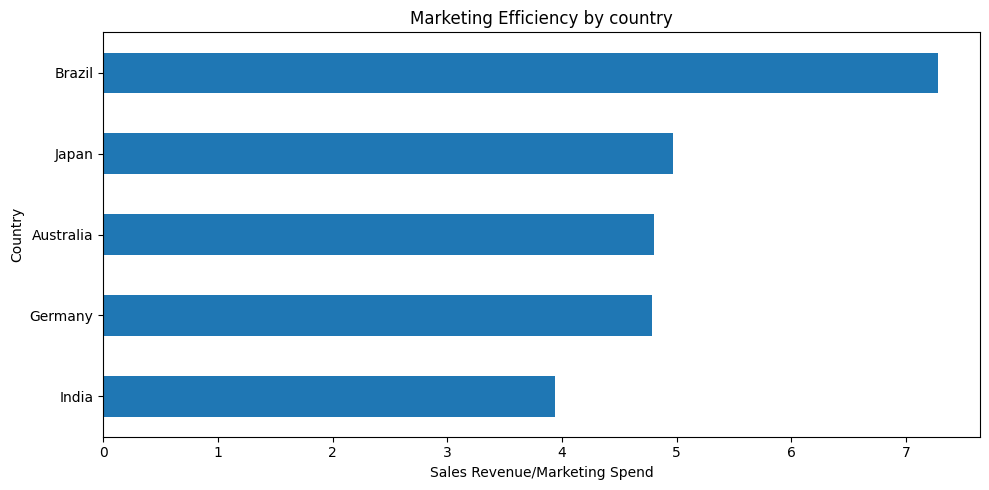

In [69]:
plt.figure(figsize=(10,5))
country_marketing['Marketing_Efficiency'].sort_values().plot(kind='barh')
plt.title('Marketing Efficiency by country')
plt.xlabel('Sales Revenue/Marketing Spend')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Marketing efficiency by product**

In [70]:
product_marketing =df.groupby('Product').agg(
    Total_Marketing_Spend=('Marketing_Spend','sum'),
    Total_Revenue=('Amount','sum'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Number_of_Orders=('Order_ID','nunique')
)
product_marketing['Marketing_Efficiency'] = (
    product_marketing['Total_Revenue'] /
    product_marketing['Total_Marketing_Spend']
)
product_marketing =product_marketing.sort_values(
    'Marketing_Efficiency',ascending=False
)
product_marketing

,Total_Marketing_Spend,Total_Revenue,Total_Boxes,Number_of_Orders,Marketing_Efficiency
Product,,,,,
Mixed Assortment Box,212298.390000,2011521.25,555792,2197,9.474972
Choco Coins Bag,61673.070000,478835.95,133826,674,7.764101
Almond Crunch Bar,88904.120074,604991.88,165368,951,6.804993
Truffle Gift Box,302349.329963,1876559.09,506790,3130,6.206593
Salted Caramel Bar,54612.090000,271998.17,74031,569,4.980549
Pralines Gift Box,128170.741212,596959.39,166881,1329,4.657532
White Choco Bar,71114.656699,322991.77,90915,717,4.541845
Hazelnut Milk Bar,48760.930000,218019.05,59564,538,4.471183
70% Dark Bar,604235.032592,2623787.65,708597,6353,4.342330


**Visualise product marketing efficiency**

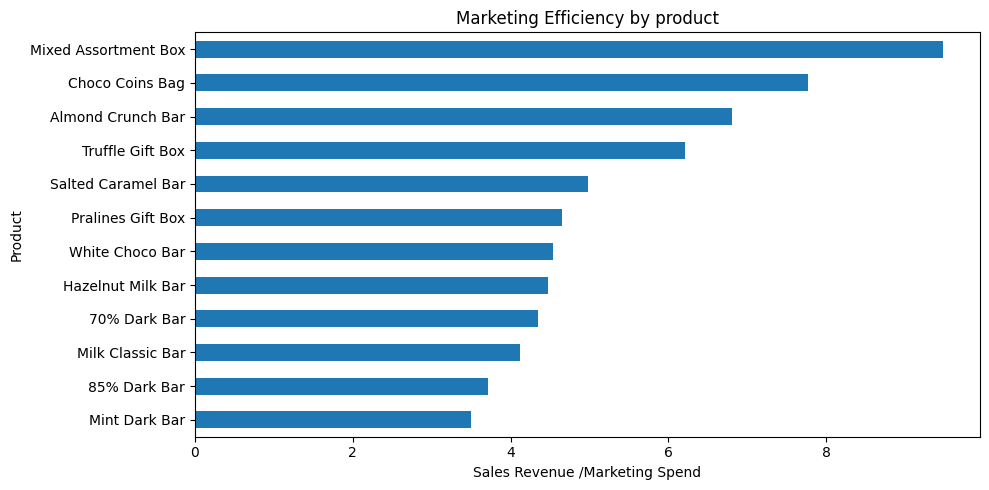

In [71]:
plt.figure(figsize=(10,5))
product_marketing['Marketing_Efficiency'].sort_values().plot(kind='barh')
plt.title('Marketing Efficiency by product')
plt.xlabel('Sales Revenue /Marketing Spend')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

**Marketing efficiency by sales channel**

In [72]:
channel_marketing = df.groupby('Channel').agg(
    Total_Marketing_Spend=('Marketing_Spend','sum'),
    Total_Revenue=('Amount','sum'),
    Total_Boxes=('Boxes_Shipped','sum'),
    Number_of_Orders=('Order_ID','nunique')
)
channel_marketing['Marketing_Efficiency'] =(channel_marketing['Total_Revenue'] / channel_marketing['Total_Marketing_Spend'])
channel_marketing=channel_marketing.sort_values('Marketing_Efficiency',ascending=False)
channel_marketing

,Total_Marketing_Spend,Total_Revenue,Total_Boxes,Number_of_Orders,Marketing_Efficiency
Channel,,,,,
Wholesale,5.710598e+05,3821504.95,1039912,5951,6.691952
Online,2.277516e+05,1115965.16,304275,2411,4.899921
Retail,1.114679e+06,5375864.21,1477040,11638,4.822793


**Visualise channel marketing efficiency**

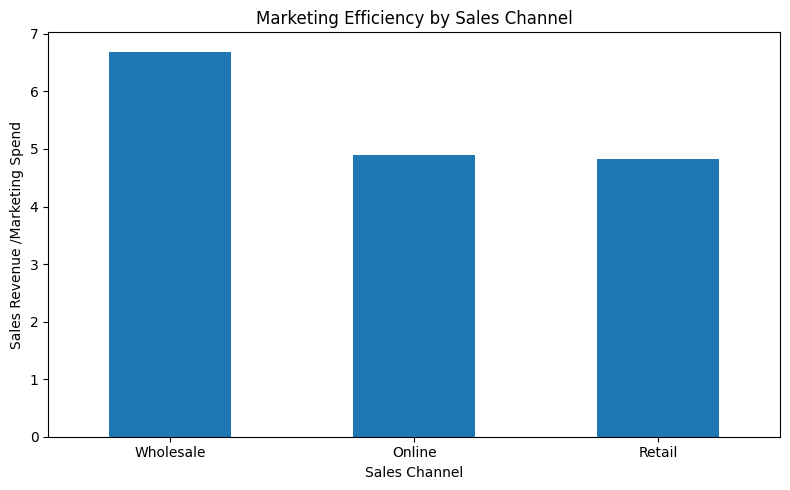

In [73]:
plt.figure(figsize=(8,5))
channel_marketing['Marketing_Efficiency'].plot(kind='bar')
plt.title('Marketing Efficiency by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Sales Revenue /Marketing Spend')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Compare marketing spend and revenue by country**

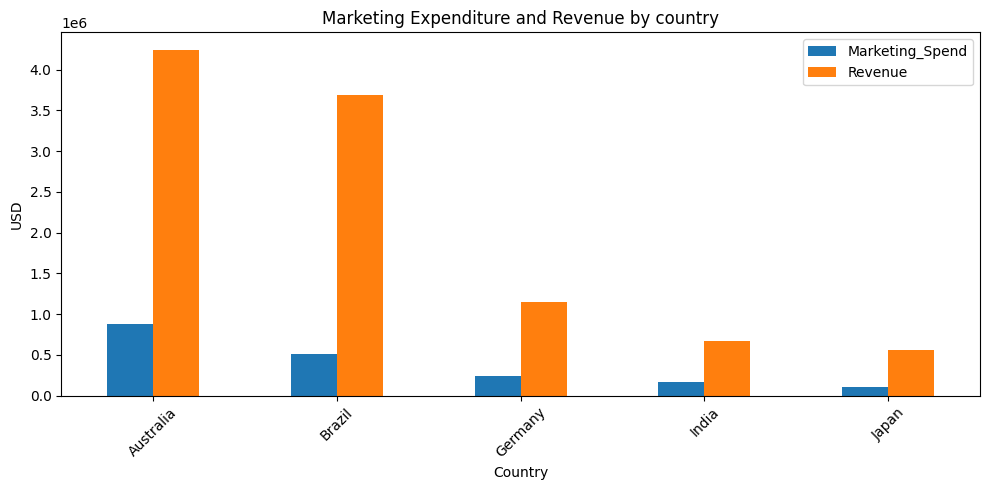

In [74]:
country_comparison = df.groupby('Country').agg(Marketing_Spend=('Marketing_Spend','sum'),Revenue=('Amount','sum'))
country_comparison.plot(kind='bar',figsize=(10,5))
plt.title('Marketing Expenditure and Revenue by country')
plt.xlabel('Country')
plt.ylabel('USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Compare marketing spend and revenue by product**

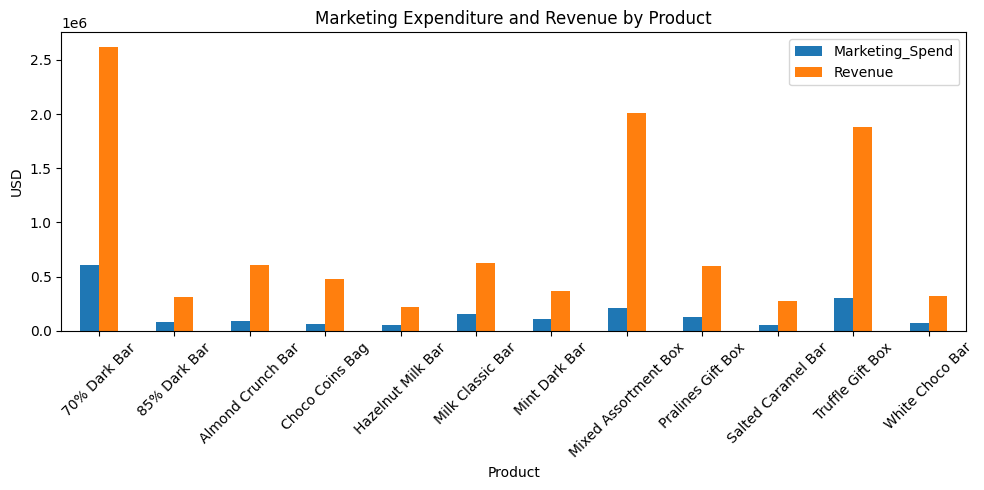

In [75]:
product_comparison =df.groupby('Product').agg(Marketing_Spend=('Marketing_Spend','sum'), Revenue=('Amount','sum'))
product_comparison.plot(kind='bar',figsize=(10,5))
plt.title('Marketing Expenditure and Revenue by Product')
plt.xlabel('Product')
plt.ylabel('USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Compare marketing spend and revenue by channel**

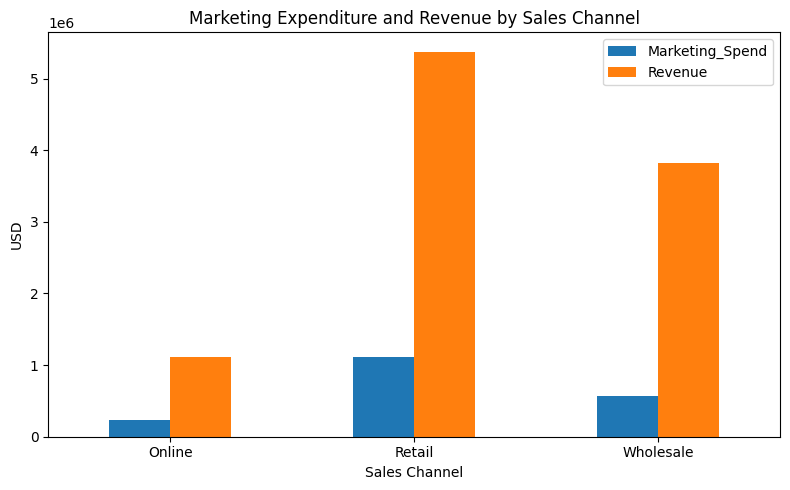

In [76]:
channel_comparison = df.groupby('Channel').agg(
    Marketing_Spend=('Marketing_Spend','sum'),
    Revenue=('Amount','sum'))
channel_comparison.plot(kind='bar',figsize=(8,5))
plt.title('Marketing Expenditure and Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Correlation heatmap**

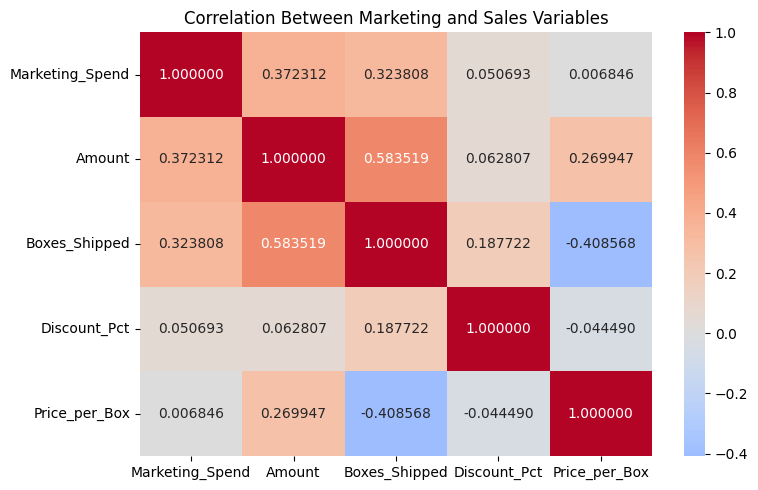

In [77]:
marketing_corr = df[['Marketing_Spend','Amount','Boxes_Shipped','Discount_Pct','Price_per_Box']].corr()
plt.figure(figsize=(8,5))
sns.heatmap(marketing_corr,annot=True,fmt='2f',cmap='coolwarm',center=0)
plt.title('Correlation Between Marketing and Sales Variables')
plt.tight_layout()
plt.show()

**Identify the top 5 countries**

In [78]:
print("Top 5 Countries by Marketing Efficiency:")
display(country_marketing[['Total_Marketing_Spend','Total_Revenue','Marketing_Efficiency']].head(5))

Top 5 Countries by Marketing Efficiency:


,Total_Marketing_Spend,Total_Revenue,Marketing_Efficiency
Country,,,
Brazil,507270.499534,3692760.52,7.279667
Japan,112108.620000,557224.63,4.970400
Australia,884290.932488,4246404.97,4.802045
Germany,240721.713700,1151477.77,4.783440
India,169098.251212,665466.43,3.935383


**Identify the top 5 products**

In [79]:
print("Top 5 Products by Marketing Efficiency:")
display(product_marketing[['Total_Marketing_Spend','Total_Revenue','Marketing_Efficiency']].head(5))

Top 5 Products by Marketing Efficiency:


,Total_Marketing_Spend,Total_Revenue,Marketing_Efficiency
Product,,,
Mixed Assortment Box,212298.390000,2011521.25,9.474972
Choco Coins Bag,61673.070000,478835.95,7.764101
Almond Crunch Bar,88904.120074,604991.88,6.804993
Truffle Gift Box,302349.329963,1876559.09,6.206593
Salted Caramel Bar,54612.090000,271998.17,4.980549


**Identify the best channel**

In [80]:
print("Sales Channels Ranked by Marketing Efficiency")
display(channel_marketing[['Total_Marketing_Spend','Total_Revenue','Marketing_Efficiency']])

Sales Channels Ranked by Marketing Efficiency


,Total_Marketing_Spend,Total_Revenue,Marketing_Efficiency
Channel,,,
Wholesale,5.710598e+05,3821504.95,6.691952
Online,2.277516e+05,1115965.16,4.899921
Retail,1.114679e+06,5375864.21,4.822793


**OBJECTIVE 4**

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import(mean_absolute_error,mean_squared_error,r2_score)

In [82]:
numeric_columns =['Discount_Pct','Marketing_Spend','Boxes_Shipped','Amount']
for col in numeric_columns:
  df[col] = pd.to_numeric(df[col],errors='coerce')


In [83]:
df[numeric_columns].dtypes

,0
Discount_Pct,float64
Marketing_Spend,float64
Boxes_Shipped,int64
Amount,float64


**Select the variables**

In [84]:
features =['Product','Country','Channel','Discount_Pct','Marketing_Spend','Boxes_Shipped']
target ='Amount'

In [85]:
model_df = df[features + [target]].copy()

In [86]:
print("Missing values before removing:")
print(model_df.isnull().sum())

Missing values before removing:
Product             0
Country             0
Channel             0
Discount_Pct        1
Marketing_Spend     0
Boxes_Shipped       0
Amount             11
dtype: int64


In [87]:
model_df = model_df.dropna()

In [88]:
print(model_df.isnull().sum())

Product            0
Country            0
Channel            0
Discount_Pct       0
Marketing_Spend    0
Boxes_Shipped      0
Amount             0
dtype: int64


In [89]:
print("\nRows available for modelling:",len(model_df))


Rows available for modelling: 19988


**Separate X and Y**

In [90]:
X =model_df[features]
y =model_df[target]

In [91]:
print("Missing Values in X:",X.isnull().sum().sum())
print("Missing values in y:",y.isnull().sum())

Missing Values in X: 0
Missing values in y: 0


**Spilt the dataset into training and testing data**

In [92]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.20,random_state=42)
print("Missing values in y_train:",y_train.isnull().sum())
print("Missing values in y_test:",y_test.isnull().sum())

Missing values in y_train: 0
Missing values in y_test: 0


In [94]:
categorical_features =['Product','Country','Channel']
numerical_features =['Discount_Pct','Marketing_Spend','Boxes_Shipped']

**Linear Regression- Create model**

In [95]:
preprocessor = ColumnTransformer(transformers=[('categorical',OneHotEncoder(handle_unknown='ignore'),categorical_features),('numerical',StandardScaler(),numerical_features)])

In [96]:
linear_model =Pipeline(steps=[('preprocessor',preprocessor),('model',LinearRegression())])

In [97]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product', 'Country',
                                                   'Channel']),
                                                 ('numerical', StandardScaler(),
                                                  ['Discount_Pct',
                                                   'Marketing_Spend',
                                                   'Boxes_Shipped'])])),
                ('model', LinearRegression())])

In [98]:
y_pred_linear = linear_model.predict(X_test)

In [99]:
mae_linear =mean_absolute_error(y_test, y_pred_linear)
rmse_linear =np.sqrt(mean_squared_error(y_test,y_pred_linear))
r2_linear =r2_score(y_test,y_pred_linear)
print("Linear Regrssion Results")
print("------------------------")
print("MAE:",round(mae_linear,2))
print("RMSE:", round(rmse_linear,2))
print("R2 Score:", round(r2_linear,3))

Linear Regrssion Results
------------------------
MAE: 157.01
RMSE: 258.81
R2 Score: 0.539


**Random Forest Regressor**

In [100]:
rf_model = Pipeline(steps=[('preprocessor',preprocessor),('model',RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1))])

In [101]:
rf_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product', 'Country',
                                                   'Channel']),
                                                 ('numerical', StandardScaler(),
                                                  ['Discount_Pct',
                                                   'Marketing_Spend',
                                                   'Boxes_Shipped'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [102]:
y_pred_rf = rf_model.predict(X_test)

In [104]:
mae_rf = mean_absolute_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Regressor Results")
print("-------------------------------")
print("MAE:",round(mae_rf,2))
print("RMSE:",round(rmse_rf,2))
print("R2 Score:",round(r2_rf,3))

Random Forest Regressor Results
-------------------------------
MAE: 97.57
RMSE: 206.67
R2 Score: 0.706


**Gradient Boosting Regressor**

In [105]:
gb_model = Pipeline(steps=[('preprocessor',preprocessor),('model',GradientBoostingRegressor(n_estimators=100,random_state=42))])

In [106]:
gb_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product', 'Country',
                                                   'Channel']),
                                                 ('numerical', StandardScaler(),
                                                  ['Discount_Pct',
                                                   'Marketing_Spend',
                                                   'Boxes_Shipped'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [107]:
y_pred_gb = gb_model.predict(X_test)

In [108]:
mae_gb = mean_absolute_error(y_test,y_pred_gb)
rmse_gb =np.sqrt(mean_squared_error(y_test,y_pred_gb))
r2_gb = r2_score(y_test,y_pred_gb)
print("Gradient Boosting Results")
print("-------------------------")
print("MAE:", round(mae_gb,2))
print("RMSE:",round(rmse_gb,2))
print("R2 Score:", round(r2_gb,3))

Gradient Boosting Results
-------------------------
MAE: 122.67
RMSE: 224.87
R2 Score: 0.652


**Compare all models**

In [110]:
results = pd.DataFrame({'Model':['Linear Regression','Random Forest','Gradient Boosting'],
                        'MAE':[mae_linear,mae_rf,mae_gb],
                        'RMSE':[rmse_linear,rmse_rf,rmse_gb],
                        'R2_Score':[r2_linear,r2_rf,r2_gb]
                        })
results


,Model,MAE,RMSE,R2_Score
0,Linear Regression,157.009074,258.812088,0.538977
1,Random Forest,97.570451,206.673806,0.706015
2,Gradient Boosting,122.668289,224.867142,0.651979


In [111]:
results.sort_values('R2_Score',ascending=False)

,Model,MAE,RMSE,R2_Score
1,Random Forest,97.570451,206.673806,0.706015
2,Gradient Boosting,122.668289,224.867142,0.651979
0,Linear Regression,157.009074,258.812088,0.538977


**Actual vs Presicted Values**

In [114]:
best_model_name = results.loc[results['R2_Score'].idxmax(),'Model']
print("Best Model:", best_model_name)

Best Model: Random Forest


In [115]:
best_predictions =y_pred_rf

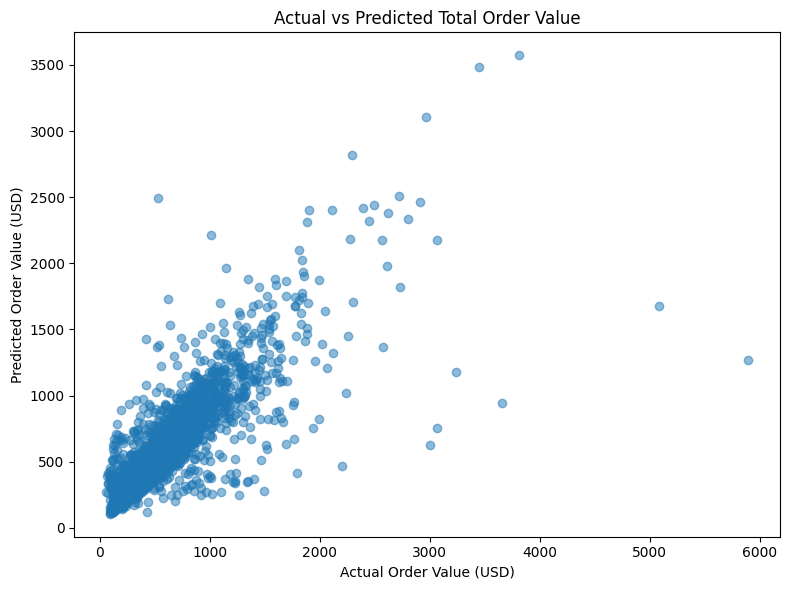

In [116]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,best_predictions,alpha=0.5)
plt.xlabel('Actual Order Value (USD)')
plt.ylabel('Predicted Order Value (USD)')
plt.title('Actual vs Predicted Total Order Value')
plt.tight_layout()
plt.show()